<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 1 - Phase 1 - Claudia

## Import `music_videos.ndjson` into a DataFrame

In [3]:
import pandas as pd
df_music_videos = pd.read_json("corpus/00_sources/music_videos.ndjson", lines=True)

df_music_videos

,id,url,title,description,language,uploader,duration,upload_date,error
0,4xqo7D2k8HM,https://www.youtube.com/watch?v=4xqo7D2k8HM,Imagine Dragons - Believer (Live in Vegas),Watch Imagine Dragons Live in Vegas on Hulu: \...,NaN,ImagineDragons,280.0,20230720.0,NaN
1,nyuo9-OjNNg,https://www.youtube.com/watch?v=nyuo9-OjNNg,I Wanna Be Yours,Provided to YouTube by Domino\n\nI Wanna Be Yo...,NaN,Official Arctic Monkeys,184.0,20141209.0,NaN
2,mRD0-GxqHVo,https://www.youtube.com/watch?v=mRD0-GxqHVo,Glass Animals - Heat Waves (Official Video),I LOVE YOU SO F***ING MUCH.\nOur fourth studio...,NaN,Glass Animals,235.0,20200629.0,NaN
3,V1Pl8CzNzCw,https://www.youtube.com/watch?v=V1Pl8CzNzCw,"Billie Eilish, Khalid - lovely",Listen to “lovely” (with Khalid): http://smart...,NaN,Billie Eilish,201.0,20180426.0,NaN
4,yKNxeF4KMsY,https://www.youtube.com/watch?v=yKNxeF4KMsY,Coldplay - Yellow (Official Video),Coldplay's tenth studio album Moon Music avail...,NaN,Coldplay,272.0,20110530.0,NaN
...,...,...,...,...,...,...,...,...,...
991,R7UrFYvl5TE,https://www.youtube.com/watch?v=R7UrFYvl5TE,Kelly Clarkson - Since U Been Gone (Official V...,"""Since U Been Gone"" performed by Kelly Clarkso...",NaN,Kelly Clarkson,192.0,20100928.0,NaN
992,4fndeDfaWCg,https://www.youtube.com/watch?v=4fndeDfaWCg,Backstreet Boys - I Want It That Way (Official...,"Official music video for ""I Want It That Way"" ...",NaN,Backstreet Boys,219.0,20091025.0,NaN
993,NaN,https://www.youtube.com/watch?v=plcmqP3b-Qg,NaN,NaN,NaN,NaN,NaN,NaN,[0;31mERROR:[0m [youtube] plcmqP3b-Qg: Video...
994,xFrGuyw1V8s,https://www.youtube.com/watch?v=xFrGuyw1V8s,ABBA - Dancing Queen (Official Music Video),REMASTERED IN HD – UP TO 4K!!\n\nListen to mor...,NaN,ABBA,233.0,20091008.0,NaN


## Create `transcript_word_count` column and replace the `error` column with a boolean indicating whether the video is available

In [4]:
import os

def get_transcript_word_count(video_id):
    if not isinstance(video_id, str):
        return 0
    filepath = f"corpus/02_music_videos_transcripts/{video_id}.txt"
    if os.path.exists(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            return len(f.read().split())
    return 0

# df_music_videos_dataset
df_music_videos_dataset = df_music_videos.copy()
df_music_videos_dataset['transcript_word_count'] = df_music_videos_dataset['id'].apply(get_transcript_word_count)
df_music_videos_dataset['available'] = df_music_videos_dataset['error'].isna()
df_music_videos_dataset = df_music_videos_dataset.drop(columns=['error'])
df_music_videos_dataset

,id,url,title,description,language,uploader,duration,upload_date,transcript_word_count,available
0,4xqo7D2k8HM,https://www.youtube.com/watch?v=4xqo7D2k8HM,Imagine Dragons - Believer (Live in Vegas),Watch Imagine Dragons Live in Vegas on Hulu: \...,NaN,ImagineDragons,280.0,20230720.0,239,True
1,nyuo9-OjNNg,https://www.youtube.com/watch?v=nyuo9-OjNNg,I Wanna Be Yours,Provided to YouTube by Domino\n\nI Wanna Be Yo...,NaN,Official Arctic Monkeys,184.0,20141209.0,166,True
2,mRD0-GxqHVo,https://www.youtube.com/watch?v=mRD0-GxqHVo,Glass Animals - Heat Waves (Official Video),I LOVE YOU SO F***ING MUCH.\nOur fourth studio...,NaN,Glass Animals,235.0,20200629.0,174,True
3,V1Pl8CzNzCw,https://www.youtube.com/watch?v=V1Pl8CzNzCw,"Billie Eilish, Khalid - lovely",Listen to “lovely” (with Khalid): http://smart...,NaN,Billie Eilish,201.0,20180426.0,117,True
4,yKNxeF4KMsY,https://www.youtube.com/watch?v=yKNxeF4KMsY,Coldplay - Yellow (Official Video),Coldplay's tenth studio album Moon Music avail...,NaN,Coldplay,272.0,20110530.0,145,True
...,...,...,...,...,...,...,...,...,...,...
991,R7UrFYvl5TE,https://www.youtube.com/watch?v=R7UrFYvl5TE,Kelly Clarkson - Since U Been Gone (Official V...,"""Since U Been Gone"" performed by Kelly Clarkso...",NaN,Kelly Clarkson,192.0,20100928.0,115,True
992,4fndeDfaWCg,https://www.youtube.com/watch?v=4fndeDfaWCg,Backstreet Boys - I Want It That Way (Official...,"Official music video for ""I Want It That Way"" ...",NaN,Backstreet Boys,219.0,20091025.0,139,True
993,NaN,https://www.youtube.com/watch?v=plcmqP3b-Qg,NaN,NaN,NaN,NaN,NaN,NaN,0,False
994,xFrGuyw1V8s,https://www.youtube.com/watch?v=xFrGuyw1V8s,ABBA - Dancing Queen (Official Music Video),REMASTERED IN HD – UP TO 4K!!\n\nListen to mor...,NaN,ABBA,233.0,20091008.0,121,True


## Descriptive statistics on the `transcript_word_count` column

In [7]:
df_music_videos_dataset["transcript_word_count"].describe()

count     996.000000
mean      166.669679
std       138.238874
min         0.000000
25%        73.000000
50%       137.500000
75%       223.250000
max      1103.000000
Name: transcript_word_count, dtype: float64

## Boxplot and Interquartile Range (IQR) for `transcript_word_count`

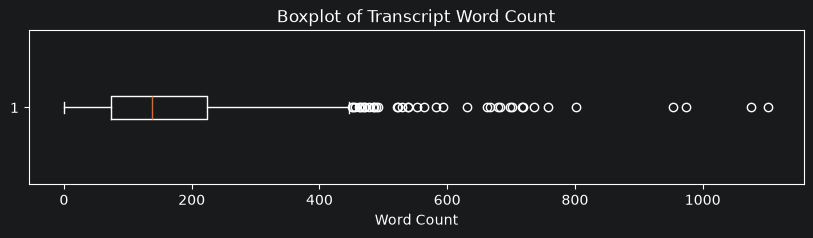

Q1 (25th percentile): 73.0
Q3 (75th percentile): 223.25
IQR: 150.25
Lower Bound (Non-outlier): -152.375
Upper Bound (Non-outlier): 448.625
Videos within the Non Outlier Range = 996
Videos within the IQR (502):
- I Wanna Be Yours: https://www.youtube.com/watch?v=nyuo9-OjNNg
- Glass Animals - Heat Waves (Official Video): https://www.youtube.com/watch?v=mRD0-GxqHVo
- Billie Eilish, Khalid - lovely: https://www.youtube.com/watch?v=V1Pl8CzNzCw
- Coldplay - Yellow (Official Video): https://www.youtube.com/watch?v=yKNxeF4KMsY
- Lord Huron - The Night We Met (Official Audio): https://www.youtube.com/watch?v=KtlgYxa6BMU
- Lady Gaga, Bruno Mars - Die With A Smile (Official Music Video): https://www.youtube.com/watch?v=kPa7bsKwL-c
- Michael Jackson - Smooth Criminal (Official Video): https://www.youtube.com/watch?v=h_D3VFfhvs4
- Queen and David Bowie - Under Pressure (Official Video): https://www.youtube.com/watch?v=a01QQZyl-_I
- AC/DC - Thunderstruck (Official Video): https://www.youtube.com/wat

In [15]:
import matplotlib.pyplot as plt

# Calculate Q1, Q3, and IQR for transcript_word_count
Q1 = df_music_videos_dataset['transcript_word_count'].quantile(0.25)
Q3 = df_music_videos_dataset['transcript_word_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Plot the boxplot
plt.figure(figsize=(10, 2))
plt.boxplot(df_music_videos_dataset['transcript_word_count'].dropna(), orientation='horizontal')
plt.title('Boxplot of Transcript Word Count')
plt.xlabel('Word Count')
plt.show()

# Print the calculated quantities
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound (Non-outlier): {lower_bound}")
print(f"Upper Bound (Non-outlier): {upper_bound}")

# Create boolean columns
within_iqr = (df_music_videos_dataset['transcript_word_count'] >= Q1) & (df_music_videos_dataset['transcript_word_count'] <= Q3)
within_non_outlier_range = (df_music_videos_dataset['transcript_word_count'] >= lower_bound) & (df_music_videos_dataset['transcript_word_count'] <= upper_bound)

# Insert the columns before 'available'
if 'within_iqr' not in df_music_videos_dataset.columns:
    available_idx = df_music_videos_dataset.columns.get_loc('available')
    df_music_videos_dataset.insert(available_idx, 'within_iqr', within_iqr)
    df_music_videos_dataset.insert(available_idx + 1, 'within_non_outlier_range', within_non_outlier_range)

# List the url and title of the music videos that fall within the IQR
within_iqr_videos = df_music_videos_dataset[df_music_videos_dataset['within_iqr']][['title', 'url']]
print(f"Videos within the Non Outlier Range = {len(within_non_outlier_range)}")
print(f"Videos within the IQR ({len(within_iqr_videos)}):")
for index, row in within_iqr_videos.iterrows():
    print(f"- {row['title']}: {row['url']}")


## Export `df_music_videos_dataset` into NDJSON, TSV and XLSX formats

In [13]:
df_music_videos_dataset.to_json('corpus/00_sources/music_videos_dataset.ndjson', orient='records', lines=True)
df_music_videos_dataset.to_csv('corpus/00_sources/music_videos_dataset.tsv', sep='	', index=False)
df_music_videos_dataset.to_excel('corpus/00_sources/music_videos_dataset.xlsx', index=False)